# Gemma 4 Vision Testing

**WeatherSpeak PH** — Gemma 4 Hackathon

## About Gemma 4 Vision

Gemma 4 is Google's open-weight multimodal language model. For this experiment:
- **Model**: Gemma 4 26B (multimodal)
- **Runtime**: Ollama (local inference)
- **Approach**: Vision-first OCR (no specialized OCR engine)

### The Hypothesis

Can a general-purpose vision-language model **replace specialized OCR** for structured government documents like PAGASA bulletins?

**Potential advantages:**
- ✅ Semantic understanding (not just character recognition)
- ✅ Natural table and structure handling
- ✅ Can extract specific fields via prompts
- ✅ Same model for OCR + translation (simpler pipeline)
- ✅ Aligns with hackathon theme (Gemma 4 throughout)

**This is the critical experiment** — if Gemma 4 Vision works well, it transforms our entire approach.

## 1. Prerequisites

**Before running this notebook**, ensure:
1. Ollama is installed: `brew install ollama` (macOS) or download from [ollama.ai](https://ollama.ai)
2. Gemma 4 model is pulled: `ollama pull gemma4:26b`
3. Ollama server is running: `ollama serve`

In [1]:
import os
import json
import base64
from pathlib import Path
from PIL import Image
import time
import requests

print("✓ Imports successful")

✓ Imports successful


## 2. Test Ollama Connection

Verify Ollama is running and Gemma 4 model is available.

In [2]:
OLLAMA_API = "http://localhost:11434"
MODEL_NAME = "gemma4:e4b"  # E4B: good accuracy, fast local inference

# Test connection
try:
    response = requests.get(f"{OLLAMA_API}/api/tags")
    models = response.json()['models']
    model_names = [m['name'] for m in models]
    
    print(f"✓ Ollama is running")
    print(f"\nAvailable models:")
    for name in model_names:
        print(f"  - {name}")
    
    if any(MODEL_NAME in name for name in model_names):
        print(f"\n✓ {MODEL_NAME} is available")
    else:
        print(f"\n⚠️  {MODEL_NAME} not found. Run: ollama pull {MODEL_NAME}")
except Exception as e:
    print(f"✗ Error connecting to Ollama: {e}")
    print(f"\nMake sure Ollama is running: ollama serve")

✓ Ollama is running

Available models:
  - gemma4:26b
  - gemma4:e2b
  - gemma4:e4b
  - gemma3:4b
  - gemma4:latest

✓ gemma4:e4b is available


## 3. Load Sample Data

Load the same sample images used for Surya and PaddleOCR.

In [3]:
# Load metadata
data_dir = Path("../data")
metadata_path = data_dir / "sample_metadata.json"

with open(metadata_path, 'r') as f:
    metadata = json.load(f)

samples = metadata['samples']
print(f"Loaded {len(samples)} sample images")

# Create output directory for results
output_dir = data_dir / "gemma4_results"
output_dir.mkdir(exist_ok=True)

Loaded 11 sample images


## 4. Helper Function: Image to Base64

Ollama API requires images to be base64-encoded.

In [4]:
def encode_image_to_base64(image_path: str) -> str:
    """Convert image file to base64 string."""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

print("✓ Helper function defined")

✓ Helper function defined


## 5. Define Prompts — Two-Step Extraction

**Step 1 — Vision → Markdown**: Gemma 4 Vision reads the image and outputs clean markdown text.  
**Step 2 — Markdown → JSON**: Gemma 4 (text-only) converts the markdown into a strict JSON object.

Thinking mode disabled on Step 2 for clean, direct JSON output.

In [5]:
# ── Step 1 prompt: Vision → Markdown ────────────────────────────────────────
VISION_SYSTEM_PROMPT = """You are an expert OCR assistant specialising in Philippine government weather documents.

Your task is to extract ALL text from the provided PAGASA typhoon bulletin image as accurately as possible.

OUTPUT RULES:
- Output clean Markdown that preserves the document's structure (headings, tables, lists, sections).
- Include every piece of visible text: headers, body, tables, footnotes, labels, legends, logos.
- For the storm track map/chart, describe what you see: storm position, forecast track, affected regions, symbols and legend items.
- Do NOT summarise, paraphrase, or omit any content.
- Do NOT add commentary or explanation outside the document content."""

VISION_USER_PROMPT = "Extract all text and describe the storm track map from this PAGASA typhoon bulletin image."

# ── Step 2 prompt: Markdown → Structured JSON ────────────────────────────────
# full_text is excluded — it's already saved as a separate markdown file.
EXTRACT_SYSTEM_PROMPT = """You are PAGASAParseAI, an expert at converting extracted PAGASA typhoon bulletin text into structured JSON.

Extract only the fields listed in the schema. Do not include full_text or any free-form text dump.

CRITICAL RULES:
- Output ONLY the JSON object. No preamble, no markdown fences, no explanation.
- If a field cannot be determined, use null or an empty array. Never hallucinate.
- forecast_positions must include every position shown (24h, 48h, 72h, 96h, 120h)."""

EXTRACT_USER_TEMPLATE = "Here is the extracted text from a PAGASA bulletin:\n\n{markdown}\n\nConvert this into the structured JSON schema."

# ── Step 2 JSON Schema — passed directly to Ollama for constrained decoding ──
# This guarantees valid JSON that matches the schema — parse failures impossible.
PAGASA_JSON_SCHEMA = {
    "type": "object",
    "properties": {
        "bulletin_type": {"type": "string", "enum": ["SWB", "TCA", "TCB", "other"]},
        "bulletin_number": {"type": ["integer", "null"]},
        "storm": {
            "type": "object",
            "properties": {
                "name": {"type": "string"},
                "international_name": {"type": ["string", "null"]},
                "category": {"type": "string", "enum": ["Tropical Depression", "Tropical Storm", "Severe Tropical Storm", "Typhoon", "Super Typhoon"]},
                "wind_signal": {"type": ["integer", "null"]}
            },
            "required": ["name", "category"]
        },
        "issuance": {
            "type": "object",
            "properties": {
                "datetime": {"type": ["string", "null"]},
                "valid_until": {"type": ["string", "null"]}
            }
        },
        "current_position": {
            "type": "object",
            "properties": {
                "latitude": {"type": ["number", "null"]},
                "longitude": {"type": ["number", "null"]},
                "reference": {"type": ["string", "null"]},
                "as_of": {"type": ["string", "null"]}
            }
        },
        "intensity": {
            "type": "object",
            "properties": {
                "max_sustained_winds_kph": {"type": ["integer", "null"]},
                "gusts_kph": {"type": ["integer", "null"]}
            }
        },
        "movement": {
            "type": "object",
            "properties": {
                "direction": {"type": ["string", "null"]},
                "speed_kph": {"type": ["integer", "null"]}
            }
        },
        "forecast_positions": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "hour": {"type": "integer"},
                    "label": {"type": "string"},
                    "latitude": {"type": ["number", "null"]},
                    "longitude": {"type": ["number", "null"]},
                    "reference": {"type": ["string", "null"]}
                },
                "required": ["hour", "label"]
            }
        },
        "affected_areas": {
            "type": "object",
            "properties": {
                "signal_1": {"type": "array", "items": {"type": "string"}},
                "signal_2": {"type": "array", "items": {"type": "string"}},
                "signal_3": {"type": "array", "items": {"type": "string"}},
                "signal_4": {"type": "array", "items": {"type": "string"}},
                "signal_5": {"type": "array", "items": {"type": "string"}},
                "rainfall_warning": {"type": "array", "items": {"type": "string"}},
                "coastal_waters": {"type": ["string", "null"]}
            }
        },
        "storm_track_map": {
            "type": "object",
            "properties": {
                "current_position_shown": {"type": "boolean"},
                "forecast_track_shown": {"type": "boolean"},
                "description": {"type": ["string", "null"]}
            }
        },
        "confidence": {"type": "number", "minimum": 0.0, "maximum": 1.0}
    },
    "required": ["bulletin_type", "storm", "issuance", "current_position", "intensity",
                 "movement", "forecast_positions", "affected_areas", "storm_track_map", "confidence"]
}

print(f"✓ Step 1 vision prompt defined ({len(VISION_SYSTEM_PROMPT)} chars)")
print(f"✓ Step 2 extraction prompt defined ({len(EXTRACT_SYSTEM_PROMPT)} chars)")
print(f"✓ JSON schema defined ({len(PAGASA_JSON_SCHEMA['properties'])} top-level fields)")

✓ Step 1 vision prompt defined (664 chars)
✓ Step 2 extraction prompt defined (469 chars)
✓ JSON schema defined (11 top-level fields)


## 6. Run Gemma 4 Vision on Sample Images

Process each sample using the simple extraction prompt.

In [6]:
TIMEOUT = 20 * 60  # 20 minutes

def step1_vision_to_markdown(image_path: str) -> str:
    """Step 1: Call Gemma 4 Vision to extract raw markdown text from the image."""
    image_b64 = encode_image_to_base64(image_path)

    payload = {
        "model": MODEL_NAME,
        "messages": [
            {"role": "system", "content": VISION_SYSTEM_PROMPT},
            {"role": "user", "content": VISION_USER_PROMPT, "images": [image_b64]}
        ],
        "stream": False
    }

    response = requests.post(f"{OLLAMA_API}/api/chat", json=payload, timeout=TIMEOUT)
    return response.json().get('message', {}).get('content', '')


def step2_markdown_to_json(markdown: str) -> tuple:
    """Step 2: Call Gemma 4 (text-only) to convert markdown into structured JSON.
    Returns (parsed_dict, parse_success, raw_response).
    Uses constrained decoding via PAGASA_JSON_SCHEMA — parse failures impossible.
    """
    user_content = EXTRACT_USER_TEMPLATE.format(markdown=markdown)

    payload = {
        "model": MODEL_NAME,
        "messages": [
            {"role": "system", "content": EXTRACT_SYSTEM_PROMPT},
            {"role": "user", "content": user_content}
        ],
        "stream": False,
        "format": PAGASA_JSON_SCHEMA  # constrained decoding — guarantees schema-valid output
    }

    response = requests.post(f"{OLLAMA_API}/api/chat", json=payload, timeout=TIMEOUT)
    raw = response.json().get('message', {}).get('content', '')

    try:
        return json.loads(raw), True, raw
    except json.JSONDecodeError:
        return {}, False, raw


print(f"✓ Functions defined (timeout: {TIMEOUT//60} minutes)")

✓ Functions defined (timeout: 20 minutes)


In [7]:
summaries = []  # lightweight metadata only — no bulk content kept in memory

structured_dir = output_dir / "structured"
structured_dir.mkdir(exist_ok=True)

for i, sample in enumerate(samples[-1:], 1):  # process only Verbena TCB#24
    stem = Path(sample['filename']).stem
    sep = '=' * 60
    print(f"\n{sep}")
    print(f"Processing {i}/{len(samples[-1:])}: {sample['filename']}")
    print(sep)

    summary = {
        'filename': sample['filename'],
        'storm': sample['storm'],
        'step1_time': 0, 'step2_time': 0, 'total_time': 0,
        'confidence': 0.0, 'parse_success': False, 'success': False
    }

    try:
        # ── Step 1: Vision → Markdown ──────────────────────────────
        print("  Step 1: Extracting text from image...")
        t1_start = time.time()
        markdown = step1_vision_to_markdown(sample['image_path'])
        t1_elapsed = time.time() - t1_start
        print(f"  ✓ Step 1 done in {t1_elapsed:.1f}s — {len(markdown)} chars extracted")

        # Save markdown immediately — do not hold it in memory past this point
        md_path = output_dir / f"{stem}_markdown.md"
        md_path.write_text(markdown, encoding='utf-8')
        print(f"  ✓ Markdown saved → {md_path.name}")

        # ── Step 2: Markdown → Structured JSON ────────────────────
        print("  Step 2: Converting to structured JSON...")
        t2_start = time.time()
        parsed, parse_success, raw_step2 = step2_markdown_to_json(markdown)
        t2_elapsed = time.time() - t2_start
        del markdown  # free memory — it is on disk now
        status = "✓" if parse_success else "✗"
        print(f"  {status} Step 2 done in {t2_elapsed:.1f}s")

        if not parse_success:
            print("  ⚠️  JSON parse failed. Raw response (first 300 chars):")
            print(f"  {raw_step2[:300]}")

        # Save structured JSON immediately
        if parse_success and parsed:
            parsed_path = structured_dir / f"{stem}_structured.json"
            with open(parsed_path, 'w', encoding='utf-8') as f:
                json.dump(parsed, f, indent=2, ensure_ascii=False)
            print(f"  ✓ Structured JSON saved → structured/{parsed_path.name}")

        confidence = parsed.get('confidence', 0.0)
        del parsed, raw_step2  # free memory — structured output is on disk

        summary.update({
            'step1_time': t1_elapsed,
            'step2_time': t2_elapsed,
            'total_time': t1_elapsed + t2_elapsed,
            'confidence': confidence,
            'parse_success': parse_success,
            'success': True
        })

        ok = "✓" if parse_success else "✗"
        print(f"\n📊 Results:")
        print(f"  Step 1 (vision→markdown): {t1_elapsed:.1f}s")
        print(f"  Step 2 (markdown→JSON):   {t2_elapsed:.1f}s")
        print(f"  Total time:               {t1_elapsed + t2_elapsed:.1f}s")
        print(f"  JSON parsed: {ok}")
        print(f"  Confidence: {confidence:.0%}")

    except Exception as e:
        print(f"  ✗ Error: {e}")
        summary['error'] = str(e)

    summaries.append(summary)

    # Persist running summary after every sample — safe to interrupt mid-run
    summary_path = output_dir / "gemma4_vision_results.json"
    with open(summary_path, 'w', encoding='utf-8') as f:
        json.dump(summaries, f, indent=2, ensure_ascii=False)
    print(f"  ✓ Summary updated → gemma4_vision_results.json ({i} sample(s))")


Processing 1/1: PAGASA_25-TC22_Verbena_TCB#24.pdf
  Step 1: Extracting text from image...
  ✓ Step 1 done in 40.9s — 3202 chars extracted
  ✓ Markdown saved → PAGASA_25-TC22_Verbena_TCB#24_markdown.md
  Step 2: Converting to structured JSON...
  ✓ Step 2 done in 35.8s
  ✓ Structured JSON saved → structured/PAGASA_25-TC22_Verbena_TCB#24_structured.json

📊 Results:
  Step 1 (vision→markdown): 40.9s
  Step 2 (markdown→JSON):   35.8s
  Total time:               76.7s
  JSON parsed: ✓
  Confidence: 100%
  ✓ Summary updated → gemma4_vision_results.json (1 sample(s))


## 7. Save Results

Save Gemma 4 Vision results for comparison.

In [8]:
# All files are already saved incrementally during the loop.
# This cell just confirms what was written.

print(f"Files saved to: {output_dir.absolute()}\n")

md_files = sorted(output_dir.glob("*_markdown.md"))
print(f"Markdown files ({len(md_files)}):")
for p in md_files:
    print(f"  {p.name}  ({p.stat().st_size:,} bytes)")

json_files = sorted((output_dir / "structured").glob("*_structured.json"))
print(f"\nStructured JSON files ({len(json_files)}):")
for p in json_files:
    print(f"  {p.name}  ({p.stat().st_size:,} bytes)")

summary_path = output_dir / "gemma4_vision_results.json"
if summary_path.exists():
    print(f"\nSummary: {summary_path.name}  ({summary_path.stat().st_size:,} bytes)")

Files saved to: /Users/josereyes/Dev/gemma4-hackathon/notebooks/../data/gemma4_results

Markdown files (11):
  PAGASA_20-19W_Pepito_SWB#01_markdown.md  (4,826 bytes)
  PAGASA_20-19W_Pepito_SWB#02_markdown.md  (4,503 bytes)
  PAGASA_22-TC02_Basyang_TCA#01_markdown.md  (3,232 bytes)
  PAGASA_22-TC02_Basyang_TCA#02_markdown.md  (3,631 bytes)
  PAGASA_23-TC08_Hanna_TCA#03_markdown.md  (3,370 bytes)
  PAGASA_23-TC08_Hanna_TCA#04_markdown.md  (3,341 bytes)
  PAGASA_25-TC02_Bising_TCA#01_markdown.md  (3,260 bytes)
  PAGASA_25-TC02_Bising_TCA#03_markdown.md  (2,822 bytes)
  PAGASA_25-TC22_Verbena_TCB#24_markdown.md  (3,204 bytes)
  PAGASA_26-TC02_Basyang_TCB#01_markdown.md  (3,281 bytes)
  PAGASA_26-TC02_Basyang_TCB#02_markdown.md  (2,926 bytes)

Structured JSON files (11):
  PAGASA_20-19W_Pepito_SWB#01_structured.json  (2,526 bytes)
  PAGASA_20-19W_Pepito_SWB#02_structured.json  (3,000 bytes)
  PAGASA_22-TC02_Basyang_TCA#01_structured.json  (2,883 bytes)
  PAGASA_22-TC02_Basyang_TCA#02_struct

## 8. Performance Summary

Aggregate performance metrics.

In [9]:
import statistics

successful = [r for r in summaries if r.get('success', False)]

print("\n" + "="*60)
print("GEMMA 4 VISION PERFORMANCE SUMMARY")
print("="*60)
print(f"\n📊 Processing:")
print(f"  Successful: {len(successful)}/{len(summaries)}")

if successful:
    t1_times = [r['step1_time'] for r in successful]
    t2_times = [r['step2_time'] for r in successful]
    total_times = [r['total_time'] for r in successful]
    parse_ok = sum(1 for r in successful if r.get('parse_success'))

    print(f"\n⏱️  Timing:")
    print(f"  Step 1 avg (vision→markdown): {statistics.mean(t1_times):.1f}s")
    print(f"  Step 2 avg (markdown→JSON):   {statistics.mean(t2_times):.1f}s")
    print(f"  Total avg per sample:         {statistics.mean(total_times):.1f}s")
    print(f"  Total min / max:              {min(total_times):.1f}s / {max(total_times):.1f}s")
    print(f"\n✅ JSON parse success: {parse_ok}/{len(successful)}")

print(f"\n✓ All results saved to: {output_dir.absolute()}")


GEMMA 4 VISION PERFORMANCE SUMMARY

📊 Processing:
  Successful: 1/1

⏱️  Timing:
  Step 1 avg (vision→markdown): 40.9s
  Step 2 avg (markdown→JSON):   35.8s
  Total avg per sample:         76.7s
  Total min / max:              76.7s / 76.7s

✅ JSON parse success: 1/1

✓ All results saved to: /Users/josereyes/Dev/gemma4-hackathon/notebooks/../data/gemma4_results


## 9. Visual Inspection

Display one sample with its extracted text for manual quality assessment.

Sample: PAGASA_25-TC22_Verbena_TCB#24.pdf
Storm: pagasa-25-TC22



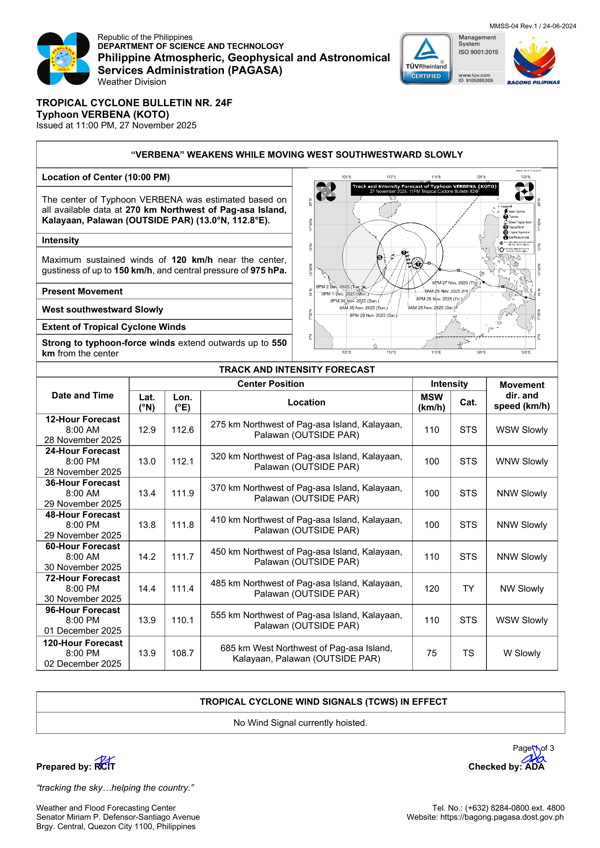


📄 EXTRACTED MARKDOWN (from saved file):
## REPUBLIC OF THE PHILIPPINES
## DEPARTMENT OF SCIENCE AND TECHNOLOGY
## PHILIPPINE ATMOSPHERIC, GEOPHYSICAL AND ASTRONOMICAL SERVICES ADMINISTRATION (PAGASA)

**TROPICAL CYCLONE BULLETIN NR. 24F**
**TYPHON VERBENA (KOTO)**
Issued at 11:00 PM, 27 November 2025

***

### Location of Center (10:00 PM)

The center of Typhoon VERBENA was estimated based on all available data at 270 km Northwest of Pag-asa Island, Kalayaan, Palawan (OUTSIDE PAR)

### Intensity

Maximum sustained winds of 120 km/h near the center, gustiness up to 150 km/h, and central pressure of 975 hPa.

### Movement

West-Southwest

### Forecast of Tropical Cyclone Winds

***

### TRACK AND INTENSITY FORECAST

| Date and Time | Lat. (N°) | Lon. (E°) | Center Position | Intensity (MSW (km/h)) | Movement (S/SW/W/NW) |
| :---: | :---: | :---: | :---: | :---: | :---: |
| 12-Hour Forecast | 12.9 | 112.6 | 275 km Northwest of Pag-asa Island, Kalayaan, Palawan (OUTSIDE PAR) | 110 | STS |

In [10]:
# Display first successful sample
successful = [r for r in summaries if r.get('success', False)]
if successful:
    sample_result = successful[0]
    sample_info = next(s for s in samples if s['filename'] == sample_result['filename'])

    print(f"Sample: {sample_result['filename']}")
    print(f"Storm: {sample_result['storm']}")
    print("\n" + "="*60)

    # Show image
    img = Image.open(sample_info['image_path'])
    display(img.resize((600, int(600 * img.size[1] / img.size[0]))))

    # Show extracted markdown (read from saved file)
    stem = Path(sample_result['filename']).stem
    md_path = output_dir / f"{stem}_markdown.md"
    if md_path.exists():
        print("\n📄 EXTRACTED MARKDOWN (from saved file):")
        print("="*60)
        print(md_path.read_text(encoding='utf-8'))
        print("="*60)

## 10. Test Structured Extraction (Optional)

Try the structured prompt on one sample to see if Gemma 4 can extract specific fields.

In [11]:
# Inspect Step 2 structured output for the first result
successful = [r for r in summaries if r.get('success', False)]
if successful:
    first = successful[0]
    stem = Path(first['filename']).stem
    print(f"Sample:        {first['filename']}")
    print(f"Success:       {first['success']}")
    print(f"Parse success: {first['parse_success']}")
    print(f"Step 1 time:   {first.get('step1_time', 0):.1f}s")
    print(f"Step 2 time:   {first.get('step2_time', 0):.1f}s")

    if first.get('error'):
        print(f"\n✗ Error: {first['error']}")

    # Load structured JSON from disk
    parsed_path = output_dir / "structured" / f"{stem}_structured.json"
    if parsed_path.exists():
        with open(parsed_path, encoding='utf-8') as f:
            parsed = json.load(f)
        print(f"\n📋 STRUCTURED JSON (from {parsed_path.name}):")
        print("="*60)
        print(json.dumps(parsed, indent=2, ensure_ascii=False))
        print("="*60)
    elif not first['parse_success']:
        print("\n⚠️  JSON parse failed — no structured output saved.")

Sample:        PAGASA_25-TC22_Verbena_TCB#24.pdf
Success:       True
Parse success: True
Step 1 time:   40.9s
Step 2 time:   35.8s

📋 STRUCTURED JSON (from PAGASA_25-TC22_Verbena_TCB#24_structured.json):
{
  "bulletin_type": "TCA",
  "storm": {
    "name": "VERBENA",
    "category": "Typhoon",
    "international_name": "KOTO",
    "wind_signal": null
  },
  "issuance": {
    "datetime": "2025-11-27 23:00:00",
    "valid_until": null
  },
  "current_position": {
    "latitude": null,
    "longitude": null,
    "reference": "270 km Northwest of Pag-asa Island, Kalayaan, Palawan (OUTSIDE PAR)"
  },
  "intensity": {
    "max_sustained_winds_kph": 120,
    "gusts_kph": 150
  },
  "movement": {
    "direction": "West-Southwest"
  },
  "forecast_positions": [
    {
      "hour": 24,
      "label": "24-Hour Forecast",
      "latitude": 13.0,
      "longitude": 112.1,
      "reference": "320 km Northwest of Pag-asa Island, Kalayaan, Palawan (OUTSIDE PAR)"
    },
    {
      "hour": 48,
      "l

## 11. Preliminary Assessment

### ✅ Potential Strengths
- Semantic understanding of document structure
- Can extract specific fields via prompts
- Same model for OCR + translation
- Aligns with hackathon theme

### ⚠️ Considerations
- Processing speed vs specialized OCR?
- Character-level accuracy?
- Consistency across different bulletin formats?
- Hallucination risk?

### 📝 Critical Questions
1. **Accuracy**: Is text extraction accurate enough for translation?
2. **Structure**: Does it preserve tables, coordinates, warnings correctly?
3. **Reliability**: Does it work consistently across all samples?
4. **Speed**: Is processing time acceptable for production?

### 🎯 Next Steps
Proceed to **Notebook 05** for comprehensive comparison across all three approaches:
- Surya OCR
- PaddleOCR
- Gemma 4 Vision

**The decision will determine our entire production pipeline.**